# EDA & Prototyping — Du Bao Gia Xang MG95
**Muc tieu:** Kham pha du lieu chuyen sau, chung minh tinh hop ly cua toan bo pipeline truoc khi chay `main.py`.

Cac phan:
1. Load & Thong ke mo ta
2. Bieu do xu huong + su kien lich su
3. Correlation Heatmap
4. Phan ra chuoi thoi gian (Decomposition)
5. ADF Test - Kiem dinh tinh dung
6. ACF / PACF — chon TIME_STEPS
7. Cross-Correlation: USD_Index & GPR -> MG95
8. Anomaly Detection + GPR
9. Feature Engineering preview
10. Sliding Window diagram
---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.data_loader import load_and_engineer, TARGET
from src.features    import adf_test, cross_correlation

plt.style.use('seaborn-v0_8-whitegrid')
SAVE = '../results/charts/'
os.makedirs(SAVE, exist_ok=True)

df = load_and_engineer('../data/processed/clean_data_exo_ver1.csv')
print(f'Shape: {df.shape}')
print(f'Period: {df.index.min().date()} -> {df.index.max().date()}')
df.describe().round(2)

Shape: (4619, 52)
Period: 2008-06-12 -> 2026-05-08


,MG97,MG95,MG92,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,BRT KH,...,Crack_Spread,Brent_WTI_Spread,Month,Quarter,DayOfWeek,Year,Month_sin,Month_cos,DOW_sin,DOW_cos
count,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,...,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00,4619.00
mean,90.24,88.40,85.55,72.15,91.65,92.49,92.06,445.86,77.43,77.56,...,16.56,5.58,6.54,2.51,2.00,2016.90,-0.01,-0.00,0.00,-0.00
std,25.86,25.69,25.27,22.67,30.16,29.62,30.00,143.94,24.52,23.77,...,8.66,6.10,3.44,1.12,1.41,5.19,0.71,0.71,0.71,0.71
min,17.15,16.12,14.64,13.60,13.06,22.92,20.75,105.89,13.24,19.15,...,-14.61,-13.70,1.00,1.00,0.00,2008.00,-1.00,-1.00,-0.95,-0.81
25%,72.56,70.65,67.77,56.00,71.76,72.76,71.46,339.88,60.22,60.56,...,11.43,1.84,4.00,2.00,1.00,2012.00,-0.87,-0.87,-0.59,-0.81
50%,85.85,84.19,81.54,69.75,87.12,87.17,87.21,437.83,74.66,74.83,...,15.66,4.38,7.00,3.00,2.00,2017.00,-0.00,-0.00,0.00,0.31
75%,111.29,109.42,106.54,89.96,117.25,117.86,118.08,561.77,98.40,98.12,...,20.71,7.42,10.00,4.00,3.00,2021.00,0.50,0.50,0.59,0.31
max,173.46,170.52,157.20,138.75,234.34,292.82,291.82,882.38,144.22,146.60,...,82.39,56.72,12.00,4.00,4.00,2026.00,1.00,1.00,0.95,1.00


## 1. Bieu do xu huong MG95 vs WTI + Su kien lich su

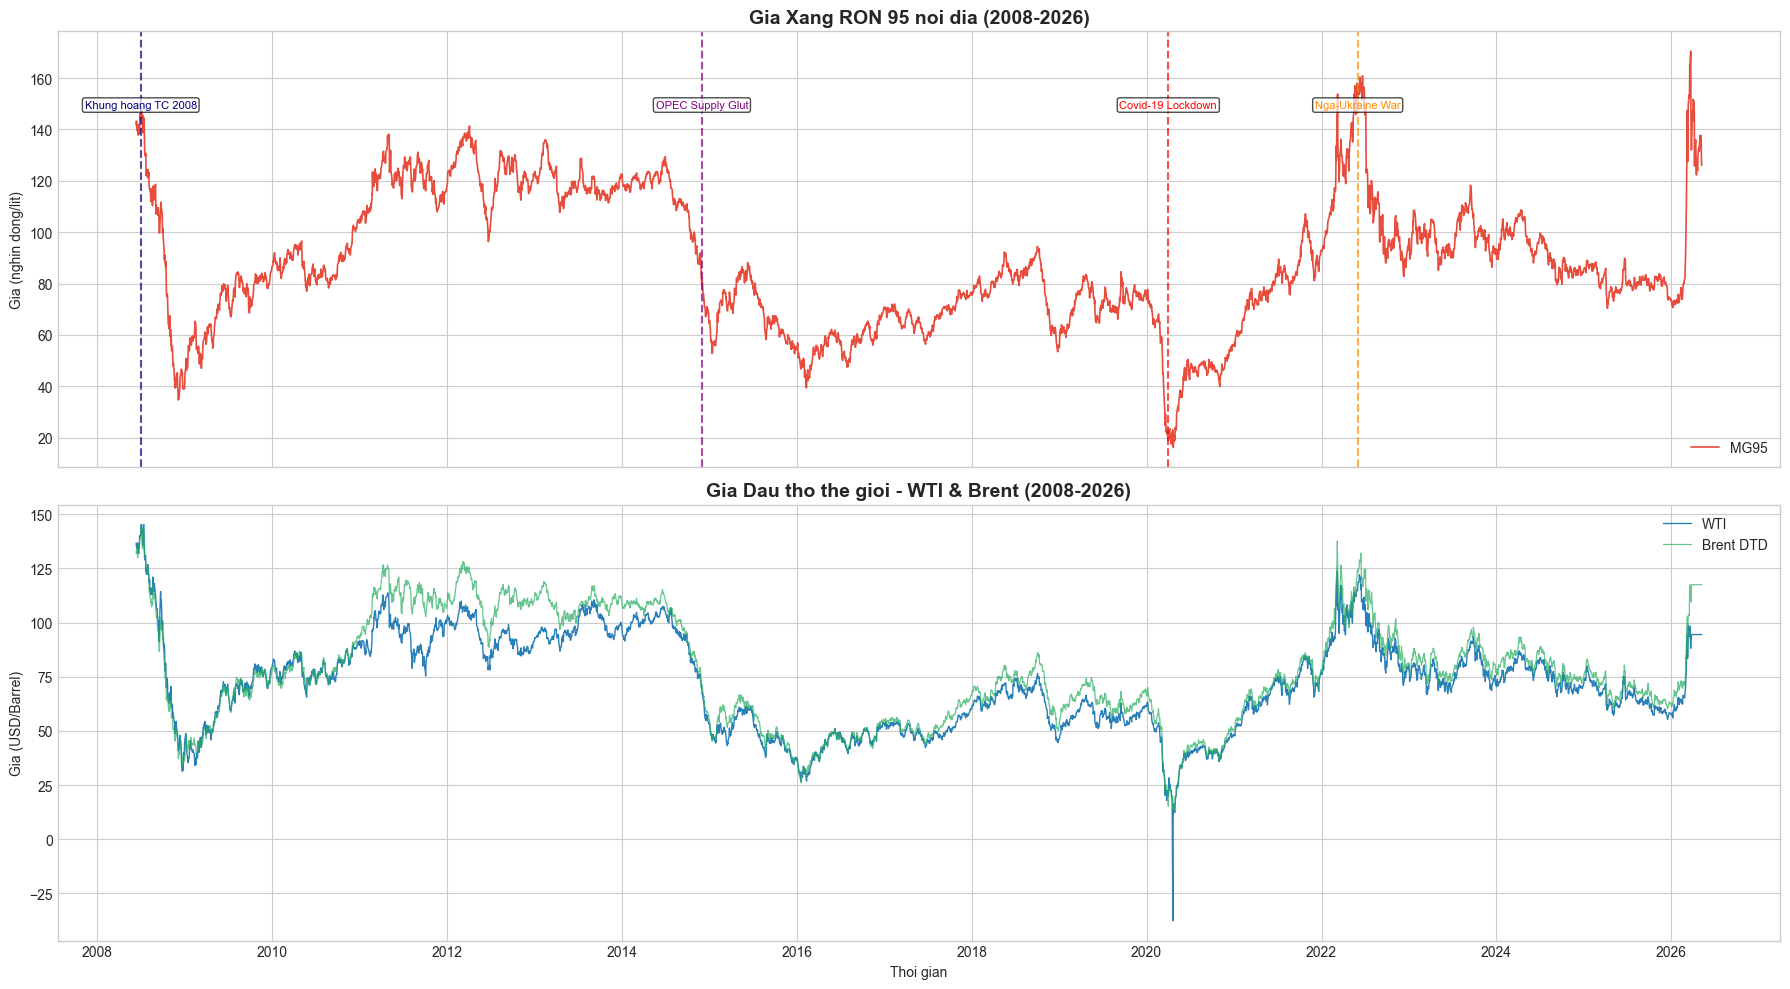

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

axes[0].plot(df.index, df['MG95'], color='#E74C3C', lw=1.2, label='MG95')
axes[0].set_title('Gia Xang RON 95 noi dia (2008-2026)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Gia (nghin dong/lit)')
axes[0].legend()

events = [
    ('2008-07-01', 'Khung hoang TC 2008', 'navy'),
    ('2014-12-01', 'OPEC Supply Glut', 'purple'),
    ('2020-04-01', 'Covid-19 Lockdown', 'red'),
    ('2022-06-01', 'Nga-Ukraine War', 'darkorange'),
]
for date_str, label, color in events:
    d = pd.Timestamp(date_str)
    if df.index.min() < d < df.index.max():
        axes[0].axvline(d, color=color, ls='--', alpha=0.7, lw=1.5)
        axes[0].annotate(label, xy=(d, df['MG95'].max()*0.87),
                         fontsize=8, color=color, ha='center',
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

axes[1].plot(df.index, df['WTI'],     color='#2980B9', lw=1.0, label='WTI')
axes[1].plot(df.index, df['BRT DTD'], color='#27AE60', lw=0.9, alpha=0.7, label='Brent DTD')
axes[1].set_title('Gia Dau tho the gioi - WTI & Brent (2008-2026)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Gia (USD/Barrel)')
axes[1].set_xlabel('Thoi gian')
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE+'eda_trend_mg95_wti.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Correlation Heatmap

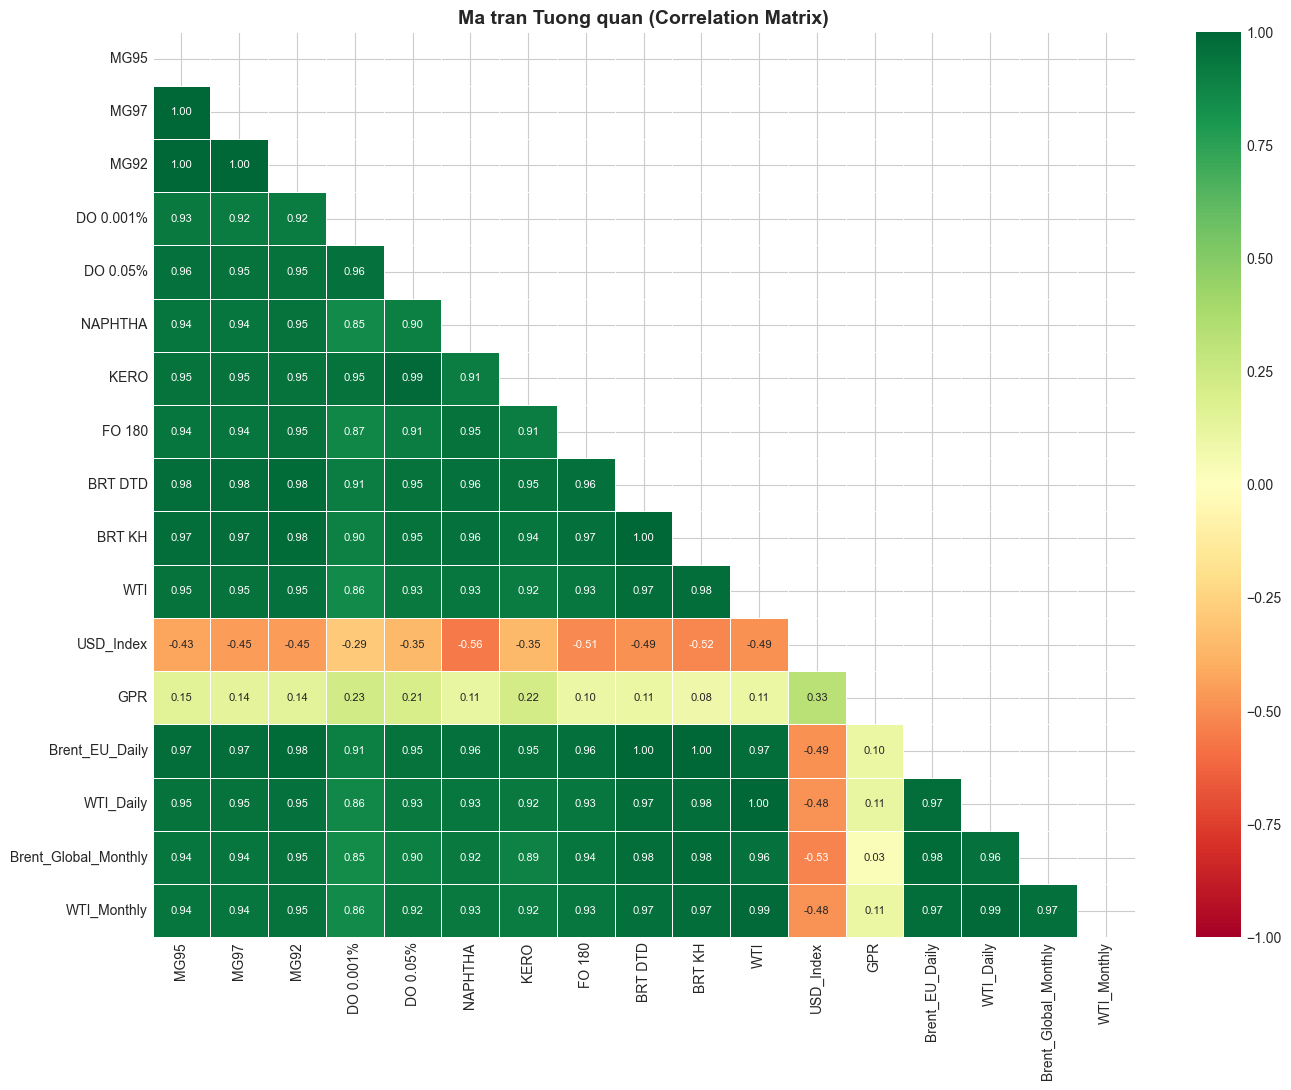

Top 8 bien tuong quan cao nhat voi MG95:
MG95              1.000000
MG92              0.998802
MG97              0.998525
BRT DTD           0.975654
Brent_EU_Daily    0.974655
BRT KH            0.971315
DO 0.05%          0.955034
KERO              0.952399
WTI               0.948284
Name: MG95, dtype: float64


In [3]:
base_cols = ['MG95','MG97','MG92','DO 0.001%','DO 0.05%',
             'NAPHTHA','KERO','FO 180','BRT DTD','BRT KH',
             'WTI','USD_Index','GPR','Brent_EU_Daily','WTI_Daily',
             'Brent_Global_Monthly','WTI_Monthly']
corr = df[base_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Ma tran Tuong quan (Correlation Matrix)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE+'eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 8 bien tuong quan cao nhat voi MG95:')
print(corr['MG95'].abs().sort_values(ascending=False).head(9))

## 3. Time Series Decomposition (Trend / Seasonality / Residuals)

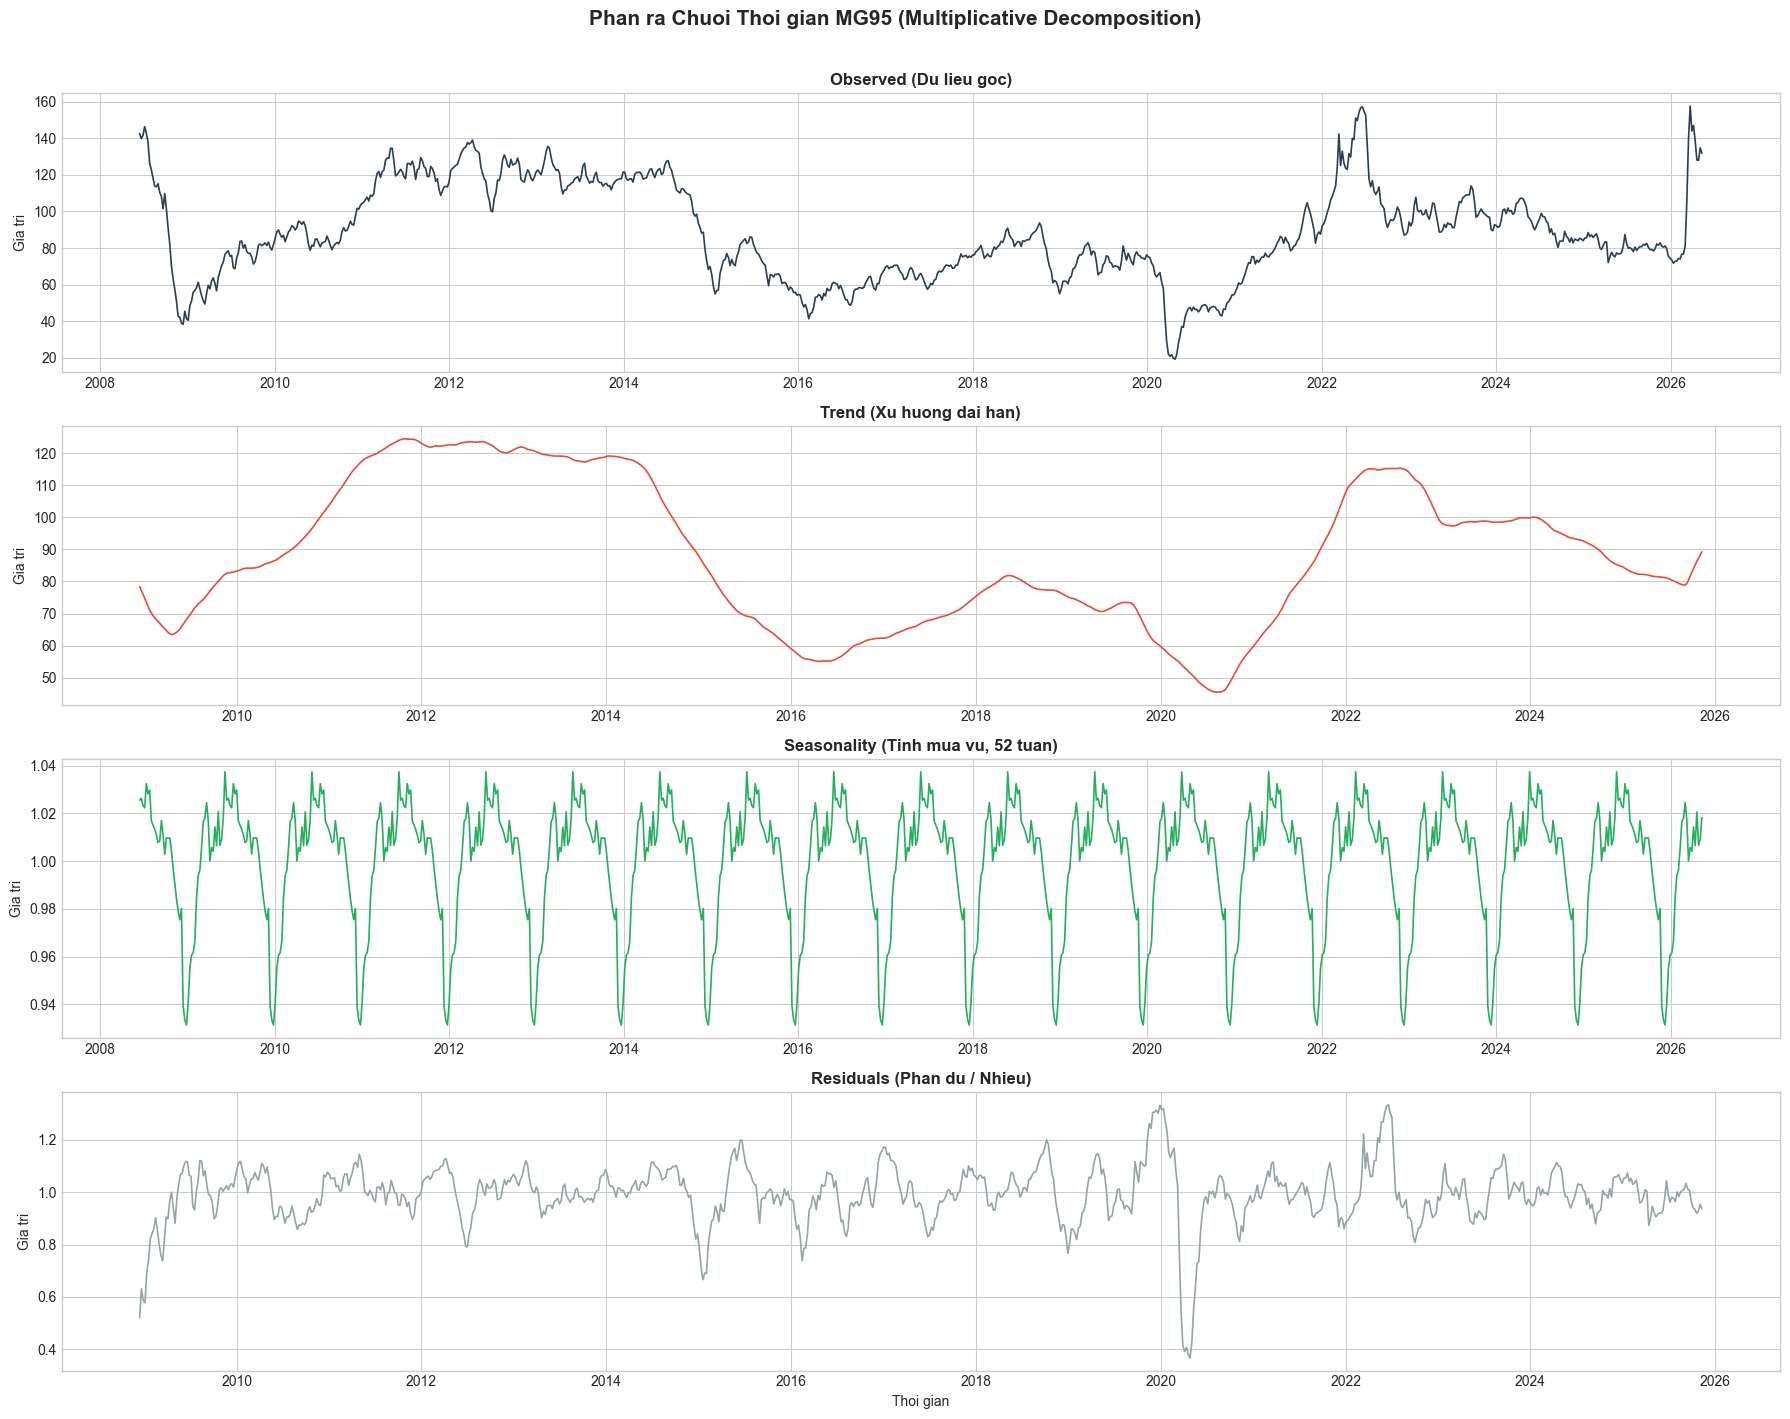

In [4]:
mg95_weekly = df['MG95'].resample('W').mean().ffill()
decomp = seasonal_decompose(mg95_weekly, model='multiplicative', period=52)

fig, axes = plt.subplots(4, 1, figsize=(18, 14))
components = [
    (mg95_weekly,    'Observed (Du lieu goc)',           '#2C3E50'),
    (decomp.trend,   'Trend (Xu huong dai han)',          '#E74C3C'),
    (decomp.seasonal,'Seasonality (Tinh mua vu, 52 tuan)','#27AE60'),
    (decomp.resid,   'Residuals (Phan du / Nhieu)',        '#95A5A6'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, lw=1.2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Gia tri')
axes[-1].set_xlabel('Thoi gian')
plt.suptitle('Phan ra Chuoi Thoi gian MG95 (Multiplicative Decomposition)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE+'eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ADF Test — Kiem dinh tinh dung


ADF Test - MG95 - Chuoi goc
  ADF Statistic : -3.1961
  p-value       : 0.020212
  Critical (1%) : -3.4318
  Critical (5%) : -2.8622
  Critical (10%) : -2.5671
  => DUNG (Stationary)

ADF Test - MG95 - Sai phan bac 1
  ADF Statistic : -12.3307
  p-value       : 0.000000
  Critical (1%) : -3.4318
  Critical (5%) : -2.8622
  Critical (10%) : -2.5671
  => DUNG (Stationary)


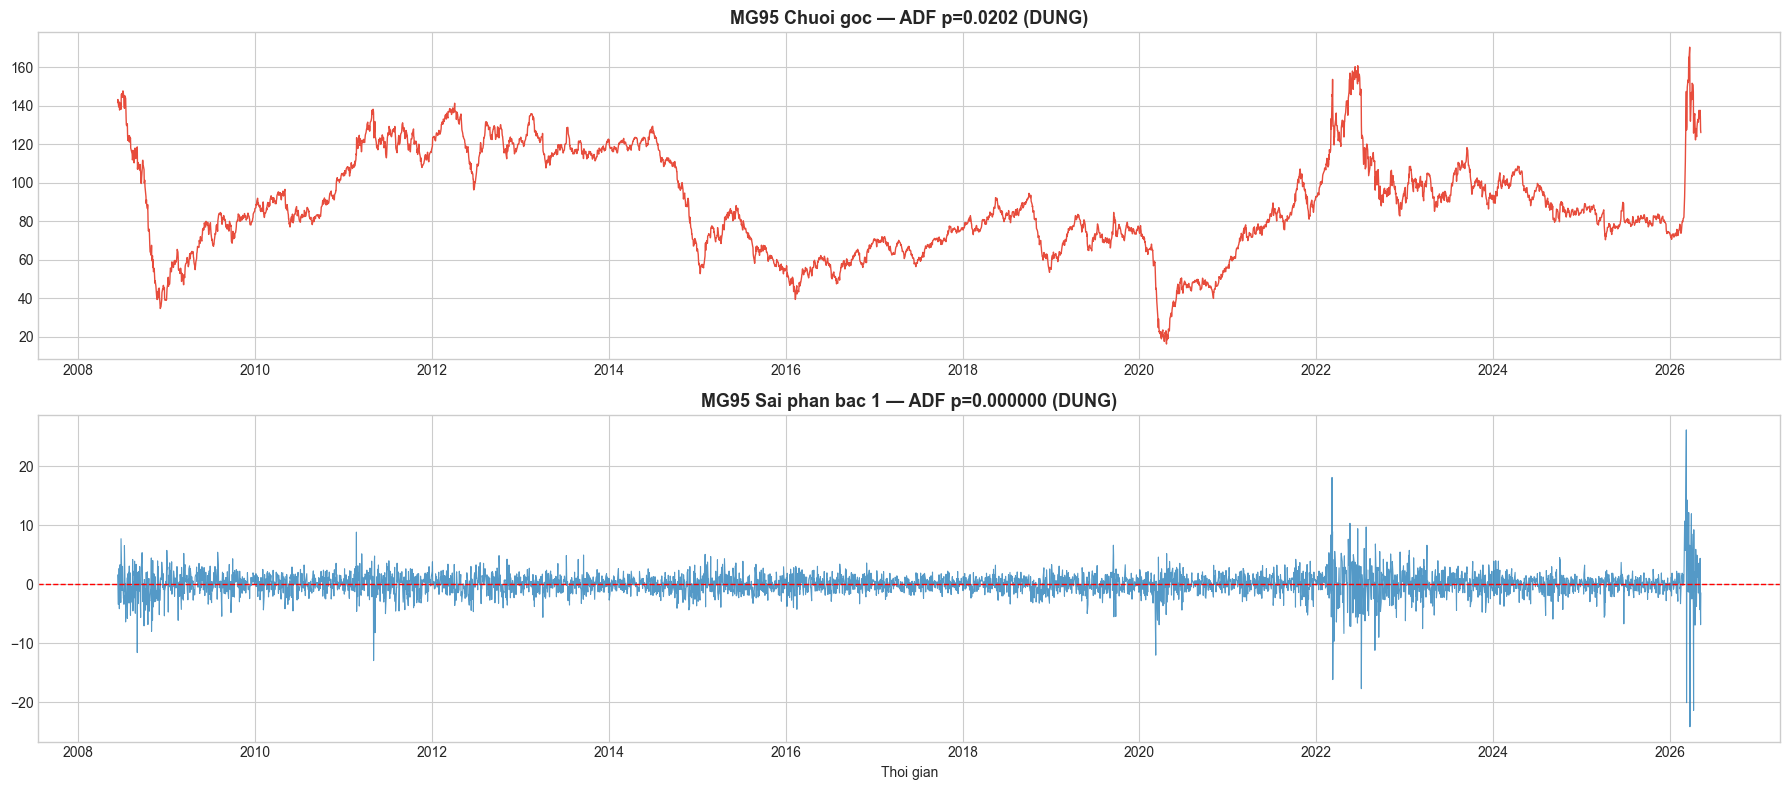

In [5]:
r0   = adf_test(df['MG95'],             'MG95 - Chuoi goc')
r1   = adf_test(df['MG95'].diff().dropna(), 'MG95 - Sai phan bac 1')

fig, axes = plt.subplots(2, 1, figsize=(18, 8))
axes[0].plot(df.index, df['MG95'], color='#E74C3C', lw=1)
axes[0].set_title(f"MG95 Chuoi goc — ADF p={r0['pvalue']:.4f} ({'DUNG' if r0['stationary'] else 'KHONG DUNG'})",
                  fontsize=13, fontweight='bold')
diff1 = df['MG95'].diff().dropna()
axes[1].plot(diff1.index, diff1.values, color='#2980B9', lw=0.8, alpha=0.8)
axes[1].axhline(0, color='red', ls='--', lw=1)
axes[1].set_title(f"MG95 Sai phan bac 1 — ADF p={r1['pvalue']:.6f} ({'DUNG' if r1['stationary'] else 'KHONG DUNG'})",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Thoi gian')
plt.tight_layout()
plt.savefig(SAVE+'eda_adf_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ACF / PACF — Chon TIME_STEPS toi uu

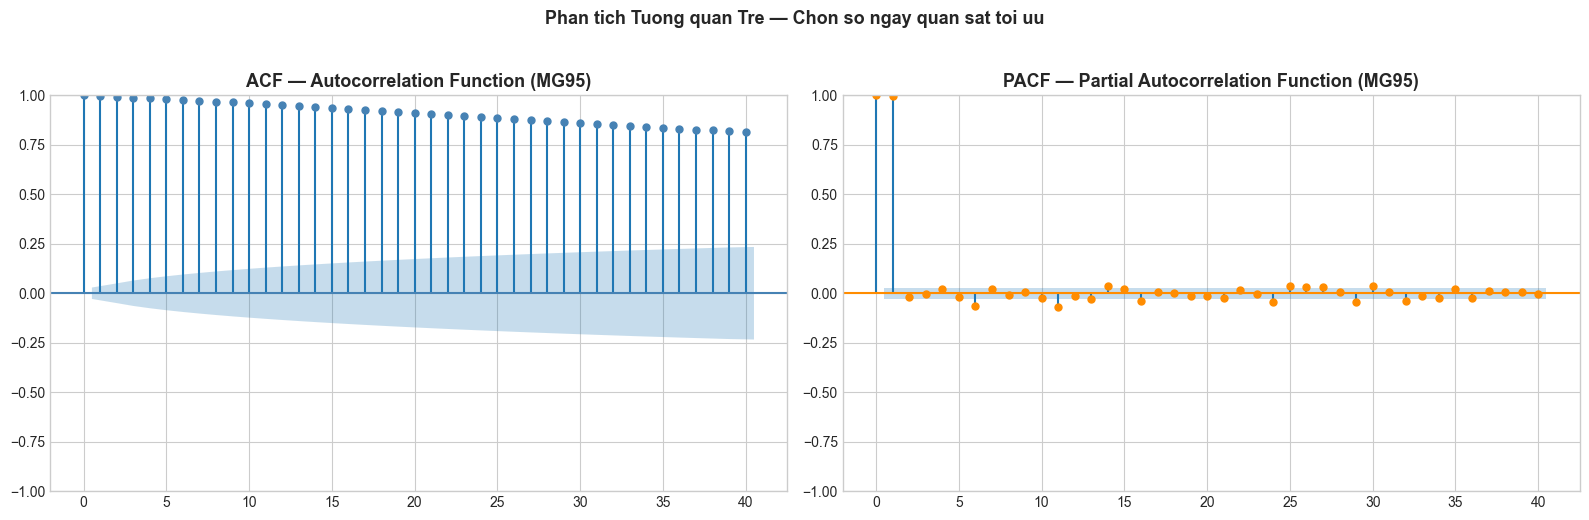

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf( df['MG95'].dropna(), lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF — Autocorrelation Function (MG95)', fontsize=13, fontweight='bold')
plot_pacf(df['MG95'].dropna(), lags=40, ax=axes[1], method='ywm', color='darkorange')
axes[1].set_title('PACF — Partial Autocorrelation Function (MG95)', fontsize=13, fontweight='bold')
plt.suptitle('Phan tich Tuong quan Tre — Chon so ngay quan sat toi uu',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(SAVE+'eda_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cross-Correlation: USD_Index & GPR -> MG95

Cross-Corr USD_Index -> MG95: best lag = 1 ngay (corr = -0.4296)
Cross-Corr GPR -> MG95: best lag = 6 ngay (corr = 0.1644)


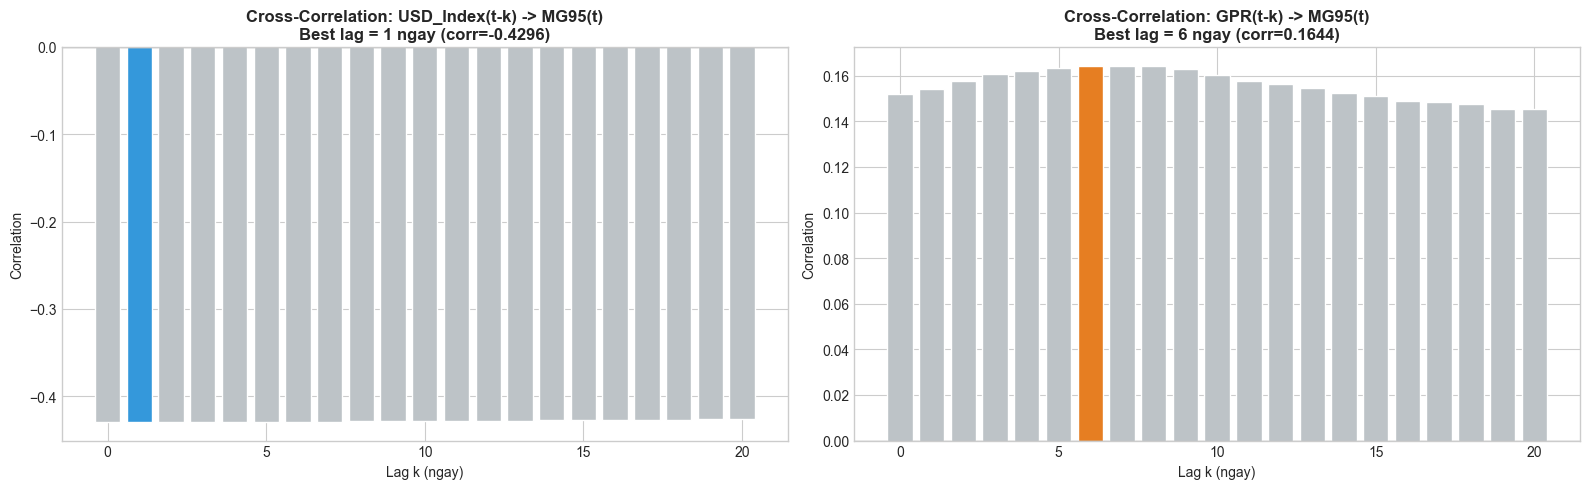

In [7]:
xcorr_usd = cross_correlation(df['USD_Index'], df['MG95'],
                               max_lag=20, name_x='USD_Index', name_y='MG95')
xcorr_gpr = cross_correlation(df['GPR'], df['MG95'],
                               max_lag=20, name_x='GPR',       name_y='MG95')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, xcorr, name, color in zip(
        axes,
        [xcorr_usd, xcorr_gpr],
        ['USD_Index', 'GPR'],
        ['#3498DB',  '#E67E22']):
    best = xcorr.abs().idxmax()
    bar_colors = [color if i == best else '#BDC3C7' for i in xcorr.index]
    ax.bar(xcorr.index, xcorr.values, color=bar_colors, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Cross-Correlation: {name}(t-k) -> MG95(t)\n'
                 f'Best lag = {best} ngay (corr={xcorr[best]:.4f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Lag k (ngay)'); ax.set_ylabel('Correlation')
plt.tight_layout()
plt.savefig(SAVE+'eda_cross_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Anomaly Detection + GPR

Outliers: 1 diem | Nguong: [12.50, 167.57]


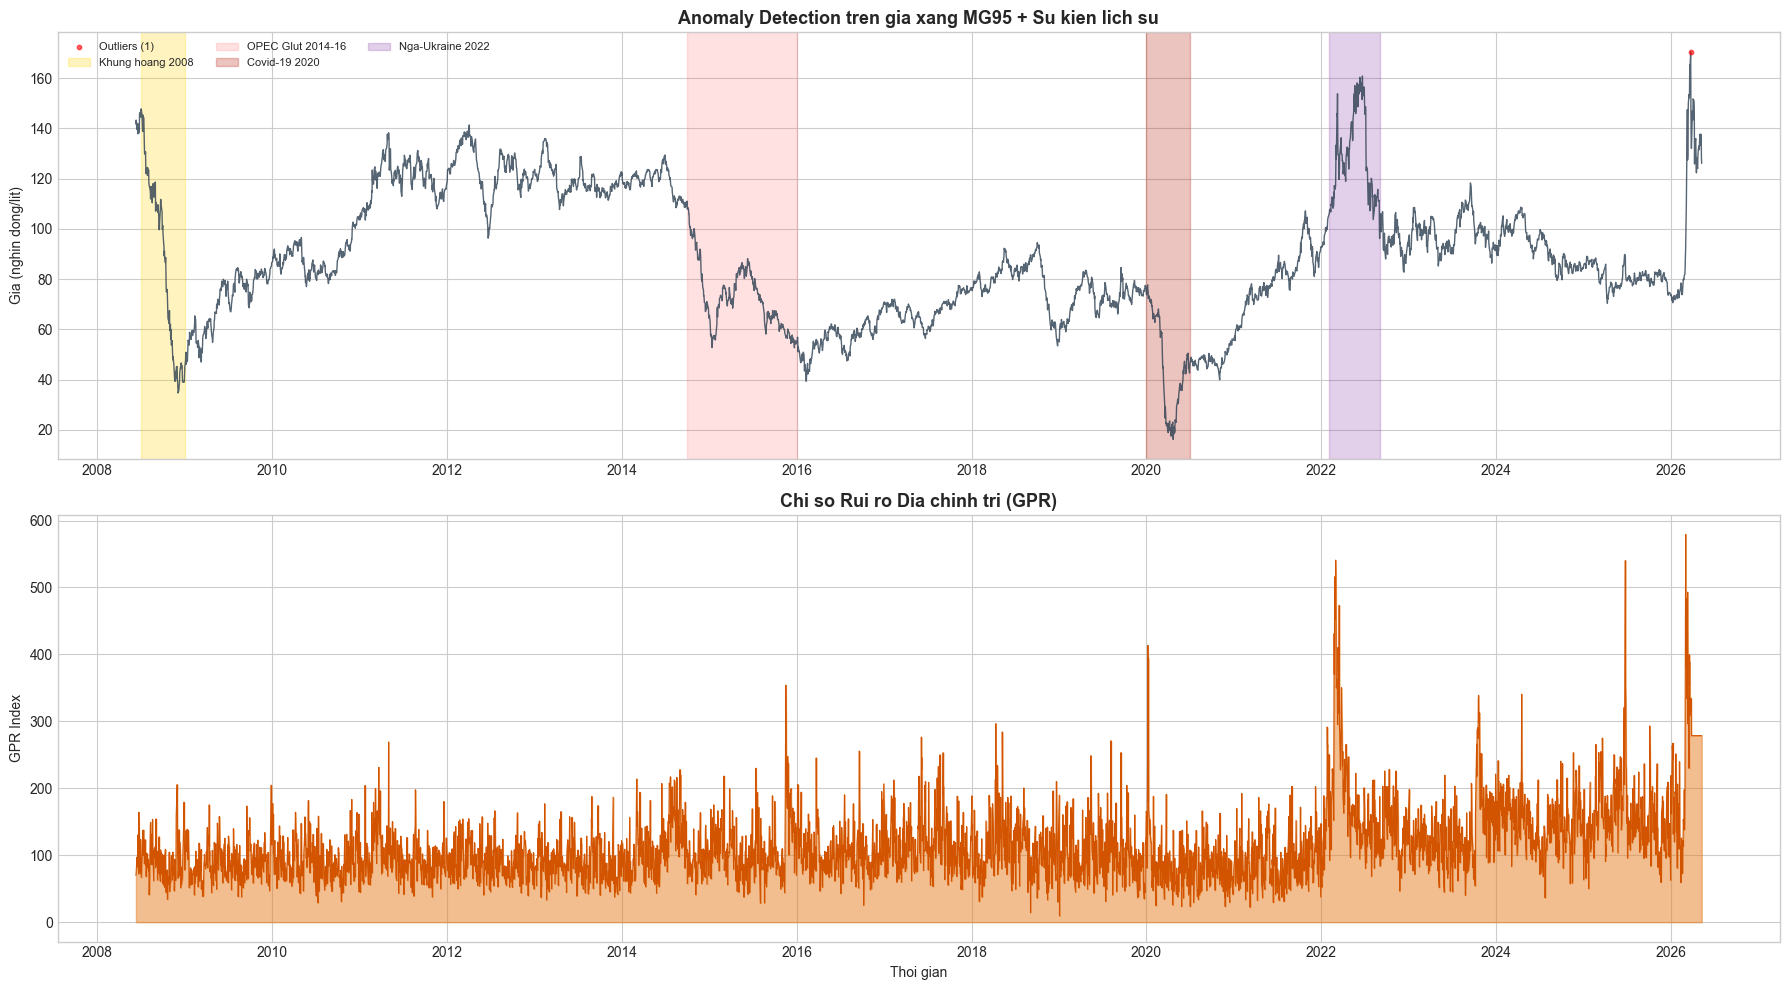

In [8]:
Q1, Q3 = df['MG95'].quantile(0.25), df['MG95'].quantile(0.75)
IQR    = Q3 - Q1
lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outs   = df[(df['MG95'] < lo) | (df['MG95'] > hi)]
print(f'Outliers: {len(outs)} diem | Nguong: [{lo:.2f}, {hi:.2f}]')

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
axes[0].plot(df.index, df['MG95'], color='#2C3E50', lw=1, alpha=0.8)
axes[0].scatter(outs.index, outs['MG95'], color='red', s=10, zorder=5,
                label=f'Outliers ({len(outs)})', alpha=0.6)

event_spans = [
    ('2008-07-01','2009-01-01','#FFD700',0.25,'Khung hoang 2008'),
    ('2014-10-01','2016-01-01','#FF6B6B',0.20,'OPEC Glut 2014-16'),
    ('2020-01-01','2020-07-01','#C0392B',0.30,'Covid-19 2020'),
    ('2022-02-01','2022-09-01','#8E44AD',0.25,'Nga-Ukraine 2022'),
]
for s, e, c, a, lbl in event_spans:
    axes[0].axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=a, color=c, label=lbl)
axes[0].set_title('Anomaly Detection tren gia xang MG95 + Su kien lich su',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Gia (nghin dong/lit)')
axes[0].legend(loc='upper left', fontsize=8, ncol=3)

axes[1].fill_between(df.index, df['GPR'], alpha=0.5, color='#E67E22')
axes[1].plot(df.index, df['GPR'], color='#D35400', lw=0.8)
axes[1].set_title('Chi so Rui ro Dia chinh tri (GPR)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('GPR Index'); axes[1].set_xlabel('Thoi gian')

plt.tight_layout()
plt.savefig(SAVE+'eda_anomaly_gpr.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Engineering Preview

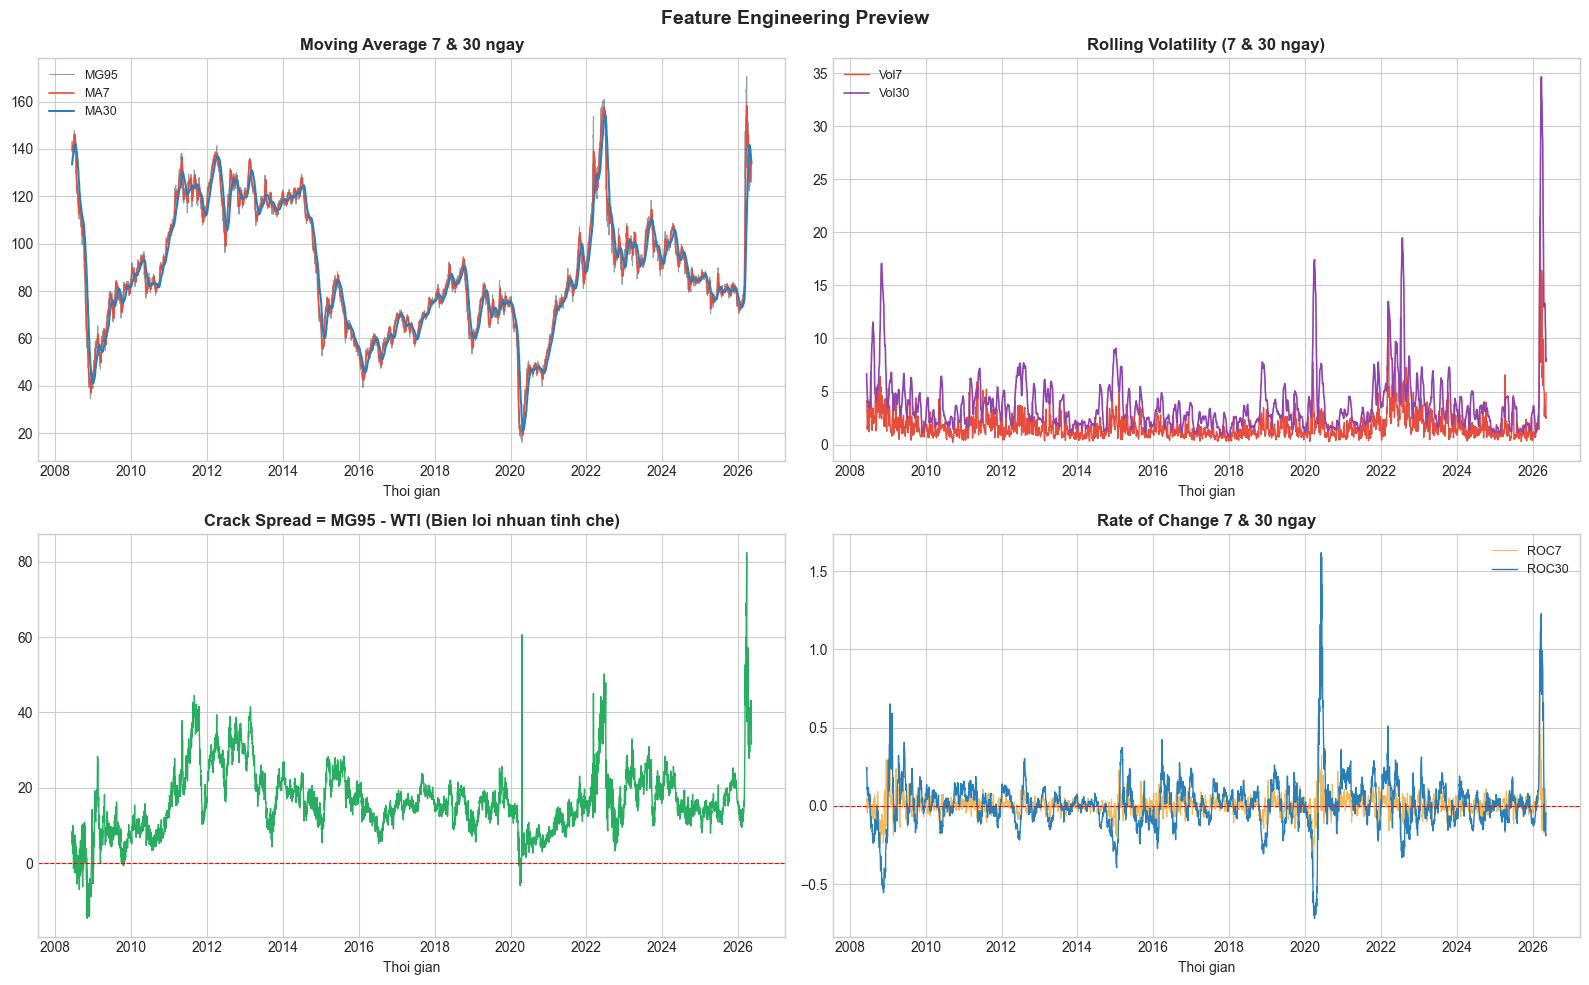

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(df.index, df['MG95'],      color='#2C3E50', lw=0.8, alpha=0.5, label='MG95')
axes[0,0].plot(df.index, df['MG95_MA7'],  color='#E74C3C', lw=1.2, label='MA7')
axes[0,0].plot(df.index, df['MG95_MA30'], color='#2980B9', lw=1.5, label='MA30')
axes[0,0].set_title('Moving Average 7 & 30 ngay', fontsize=12, fontweight='bold')
axes[0,0].legend(fontsize=9)

axes[0,1].plot(df.index, df['MG95_Vol7'],  color='#E74C3C', lw=1, label='Vol7')
axes[0,1].plot(df.index, df['MG95_Vol30'], color='#8E44AD', lw=1.2, label='Vol30')
axes[0,1].set_title('Rolling Volatility (7 & 30 ngay)', fontsize=12, fontweight='bold')
axes[0,1].legend(fontsize=9)

axes[1,0].plot(df.index, df['Crack_Spread'], color='#27AE60', lw=1)
axes[1,0].axhline(0, color='red', ls='--', lw=0.8)
axes[1,0].set_title('Crack Spread = MG95 - WTI (Bien loi nhuan tinh che)',
                     fontsize=12, fontweight='bold')

axes[1,1].plot(df.index, df['MG95_ROC7'],  color='#F39C12', lw=0.8, alpha=0.7, label='ROC7')
axes[1,1].plot(df.index, df['MG95_ROC30'], color='#2980B9', lw=1.0, label='ROC30')
axes[1,1].axhline(0, color='red', ls='--', lw=0.8)
axes[1,1].set_title('Rate of Change 7 & 30 ngay', fontsize=12, fontweight='bold')
axes[1,1].legend(fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('Thoi gian')

plt.suptitle('Feature Engineering Preview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE+'eda_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Sliding Window Diagram

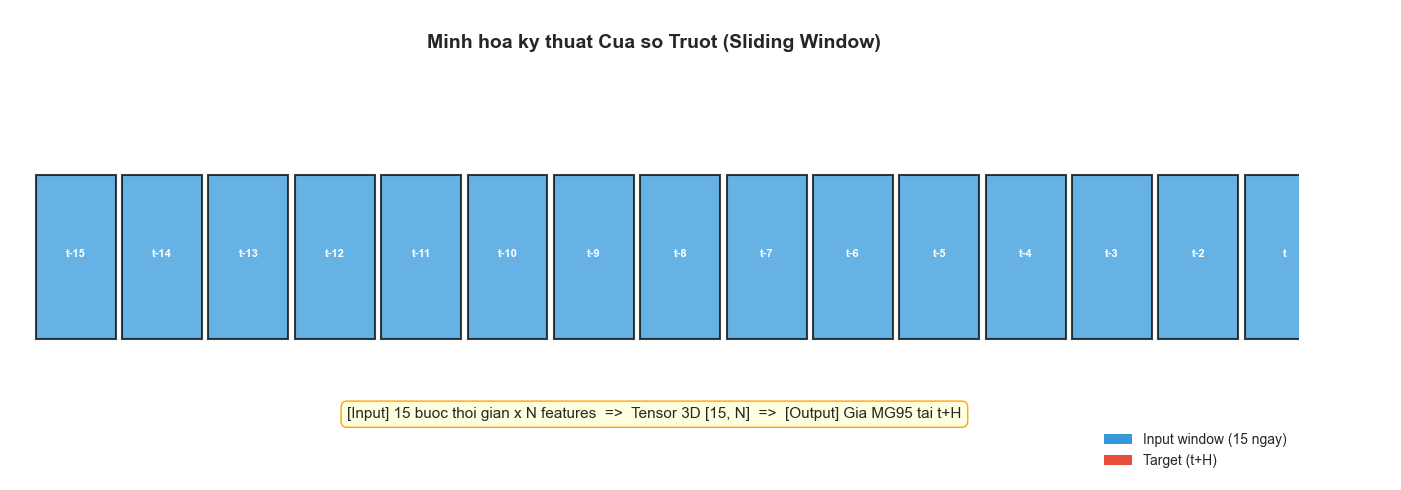

Tat ca EDA charts da luu vao results/charts/


In [10]:
from matplotlib.patches import Patch
TIME_STEPS = 15
N_SHOW = TIME_STEPS + 1

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
ax.text(0.5, 0.95, 'Minh hoa ky thuat Cua so Truot (Sliding Window)',
        ha='center', va='top', fontsize=14, fontweight='bold', transform=ax.transAxes)

W = 0.062
for i in range(N_SHOW):
    fc = '#3498DB' if i < TIME_STEPS else '#E74C3C'
    lbl = f't-{TIME_STEPS-i}' if i < TIME_STEPS - 1 else ('t' if i < TIME_STEPS else 't+1\n(Target)')
    rect = plt.Rectangle((i*(W+0.005)+0.02, 0.3), W, 0.35,
                          lw=1.5, ec='black', fc=fc, alpha=0.75,
                          transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(i*(W+0.005)+0.02+W/2, 0.48, lbl,
            ha='center', va='center', fontsize=8,
            fontweight='bold', color='white', transform=ax.transAxes)

ax.text(0.5, 0.14,
        f'[Input] {TIME_STEPS} buoc thoi gian x N features  =>  Tensor 3D [{TIME_STEPS}, N]  =>  [Output] Gia MG95 tai t+H',
        ha='center', va='center', fontsize=11, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='orange'))

legend_els = [Patch(fc='#3498DB', label=f'Input window ({TIME_STEPS} ngay)'),
              Patch(fc='#E74C3C', label='Target (t+H)')]
ax.legend(handles=legend_els, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(SAVE+'eda_sliding_window.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tat ca EDA charts da luu vao results/charts/')